<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/Copy_of_2026GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["TORCHINDUCTOR_FREEZE_PCH"] = "1"
# Also force Inductor to use a fresh directory if the previous one is locked
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_compile_fresh"

In [42]:

import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F

class LELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = math.pi / math.sqrt(3.0) #logistic CDF matched scale beats gelu and is less expensive

    def forward(self, x):
        return x * torch.sigmoid(self.scale * x)



class RoPE(nn.Module):
    def __init__(self, dim, max_len=4096):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        w_max = torch.pi / 2 #highest frequency- one rotation in 4 tokens
        w_min = torch.pi / (max_len) #this sets the lowest scale to that sufficient to resolve needle at depth.
        #most effectively, set your context size to more than you ever intend to handle
        B = 10
        setfreqs_hi = torch.logspace(
                    start=math.log(w_min,B),
                    end=math.log(w_max,B),
                    steps=(dim // 4),
                    base=B
                )


        setfreqs_lo = w_max - torch.logspace(
            start=math.log(w_min,B),
            end=math.log(w_max,B),
            steps=(dim // 4) + 1,
            base=B
        )[:-1] # Drop last to match size and allow a smooth continuation

                # Combine
        setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))
        inv_freq, _ = torch.sort(setfreqs,descending=True) #this give us a sigmoidal distribution of frequencies.
        #many large, many small, few near the midpoint.

        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        self.register_buffer('cos_cached', freqs.cos())
        self.register_buffer('sin_cached', freqs.sin())

    def get_embeddings(self, positions, device):
        positions = positions.clamp(0, self.max_len - 1).long()
        cos = F.embedding(positions, self.cos_cached).unsqueeze(0).unsqueeze(0) # [1, 1, T, D]
        sin = F.embedding(positions, self.sin_cached).unsqueeze(0).unsqueeze(0)
        return cos, sin

    def forward(self, x, positions=None):
        # x: (B, H, T, D) where D = self.dim (head_dim)
        if positions is None:
            T = x.shape[-2]
            positions = torch.arange(T, device=x.device)

        cos, sin = self.get_embeddings(positions, x.device)
        # cos, sin: [1, 1, T, D//2]

        D = x.shape[-1]
        mid = D // 2
        h1 = x[..., :mid]   # first half of dimensions
        h2 = x[..., mid:]   # second half of dimensions

        # Adjacent pairing within each half:
        # h1 pairs: (h1[0],h1[1]), (h1[2],h1[3]), ...
        # h2 pairs: (h2[0],h2[1]), (h2[2],h2[3]), ...
        #
        # h1 gets sign-flipped convention (sin term adds instead of subtracts)
        # h2 gets standard convention
        #
        # This is achieved by negating the "b" element of each pair in h1
        # before feeding into the standard rotation formula.

        # For h1: negate odd-indexed elements, apply rotation, un-negate
        # Equivalent to: the kernel contribution for h1 pairs becomes
        #   S * cos(w*d) + A * sin(w*d)
        # instead of
        #   S * cos(w*d) - A * sin(w*d)

        # Extract paired elements for h1
        h1_a = h1[..., 0::2]   # even indices (the "real" part)
        h1_b = h1[..., 1::2]   # odd indices (the "imaginary" part)

        # Extract paired elements for h2
        h2_a = h2[..., 0::2]
        h2_b = h2[..., 1::2]

        # Split cos/sin for the two halves' frequency ranges
        # First D//4 frequencies go to h1, last D//4 to h2
        n_pairs_per_half = mid // 2  # D//4
        cos1 = cos[..., :n_pairs_per_half]
        sin1 = sin[..., :n_pairs_per_half]
        cos2 = cos[..., n_pairs_per_half:]
        sin2 = sin[..., n_pairs_per_half:]

        # H1: flipped convention (negate b before rotation)
        # Standard rotation on (a, -b):
        #   out_a = a * cos - (-b) * sin = a * cos + b * sin
        #   out_b_neg = a * sin + (-b) * cos = a * sin - b * cos
        # Then un-negate b: out_b = -(a * sin - b * cos) = -a * sin + b * cos
        out_h1_a = h1_a * cos1 + h1_b * sin1
        out_h1_b = -h1_a * sin1 + h1_b * cos1

        # H2: standard convention
        #   out_a = a * cos - b * sin
        #   out_b = a * sin + b * cos
        out_h2_a = h2_a * cos2 - h2_b * sin2
        out_h2_b = h2_a * sin2 + h2_b * cos2

        # Reassemble: interleave a,b back into adjacent pairs
        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)



class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_bottle(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd,  config.n_embd//4, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd//4, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        dim = config.n_embd
        self.head_dim = dim // self.n_heads
        self.skew_basis = nn.Parameter(
            torch.randn(self.n_heads, self.head_dim, self.head_dim) * 0.02
        )

        self.g_proj = nn.Linear(dim, dim, bias=False)

        self.q_proj = nn.Linear(dim, dim, bias=False)
        self.v_proj = nn.Linear(dim, dim, bias=False)
        self.o_proj = nn.Linear(dim, dim, bias=False)
        nn.init.eye_(self.q_proj.weight) # Identity Init
        self.v_sink_residual = nn.Parameter(torch.zeros(1, 1, 1, self.head_dim))
        self.v_sink_basis = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))

        self.mask = None #set in GPT main at model time to ensure its on GPU
        self.rope = config.rope
        limit = config.block_size // 2

        self.sd_alpha = 0.3
        self.sd_sigma = config.block_size / 2.0
        alphas = torch.linspace(0, 1, self.n_heads).view(1, self.n_heads, 1, 1)
        self.register_buffer('k_alpha', alphas)

    def get_orthogonal_matrix(self):
        # A = M - M.T (Skew symmetric)
        # We broadcast the transpose over the last two dims
        skew = self.skew_basis - self.skew_basis.transpose(-1, -2)

        # Matrix Exp for each head independently
        # Result: [H, D_h, D_h]
        return torch.matrix_exp(skew)

    def forward(self, x,v_k):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        # Get per-head rotations
        Rs = self.get_orthogonal_matrix() # [H, D, D]

        # 1. Reshape q_proj weight to [H, D_h, Dim]
        W_q = self.q_proj.weight.view(self.n_heads, self.head_dim, -1)

        # 2. Rotate each head's slice of the weight matrix
        # [H, D, D] @ [H, D, Dim] -> [H, D, Dim]
        W_k_heads = Rs @ W_q

        # 3. Flatten back to [Dim, Dim] for the linear layer
        # This effectively constructs a Block-Diagonal W_k
        W_k = W_k_heads.view(-1, self.n_embd)

        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        k = F.linear(x, W_k).view(B, T, H, D).transpose(1, 2)
        g = self.g_proj(x).view(B, T, H, D).transpose(1, 2)
        if v_k is not None:
          new_k, new_g = torch.chunk(v_k, 2, dim=-1)




        #now, why is k a rotation on Q?
        #ensures k cannot sacrifice to q, q pressures ansi and wants iso
        #make all a tradeoff. realistically sufficient to pair them- one is lookup into other.
        #using reflection here instead of a proper aux loss on k to promote iso is for simplification.
        #the difference has not been ablated.

        # After k is computed and reshaped to (B, H, T, D), before RoPE:
        half_h = H // 2

        # After computing local k, before blending:
        k_local = k.clone()  # save the pre-blend version

        if v_k is not None:
            k = self.k_alpha * k + (1 - self.k_alpha) * new_k


        new_k = k.clone()  # always propagate the blend forward

        # Now selectively revert some heads to local
        if self.training:
            # per-head coin flip: (1, H, 1, 1)
            gate = torch.bernoulli(torch.full((1, H, 1, 1), 0.5, device=x.device)).bool()
            k = torch.where(gate, k, k_local)

        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)
        q = F.rms_norm(q, (D,)) #never ever norm k, you stupid fuck

        q = self.rope(q)
        k = self.rope(k)

        if v_k is not None:
            v = self.k_alpha * v + (1 - self.k_alpha) * new_g

        # Soft Attention
        scores = (q @ k.transpose(-2, -1))

        mask = self.mask[:, :, :T, :T]

        soft_scores = F.softplus(scores)
        # STE: Forward sets small/neg values to 0, Backward ignores the zeroing
        # Values < 1e-6 do not participate in mass/scaling but receive gradients
        threshold = 1e-6
        pruned_scores = torch.where(soft_scores < threshold, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned_scores - soft_scores).detach()

        soft_scores = soft_scores.masked_fill(mask == 0, 0.0) #prevent cheating here

        if self.training:
            # Create Distance Matrix [T, T]
            # dist[i, j] = i - j
            # We only care about positive distances (j <= i), which causal mask handles
            indices = torch.arange(T, device=x.device)
            dist = indices.view(-1, 1) - indices.view(1, -1)

            # Gaussian Decay Profile
            # P(drop) is high when dist is small (Recent)
            # P(drop) is low when dist is large (Distant)
            # We clamp dist to 0 to avoid NaNs, though masking handles it


            # Broadcast probabilities to batch/heads [1, 1, T, T]
            dist = dist.float().clamp(min=0)
            drop_probs = self.sd_alpha * torch.exp(-(dist**2) / (2 * self.sd_sigma**2))

            # Align dimensions: [1, 1, T, T]
            drop_probs = drop_probs.unsqueeze(0).unsqueeze(0)

            #dont allow damage to the first half, regardless
            #limited suppot positions do not get eroded
            limit = T // 2
            absolute_cutoff_mask = (dist > limit)
            drop_probs = drop_probs.masked_fill(absolute_cutoff_mask, 0.0)
            #Expand BEFORE sampling to ensure atomic independence
            # We must explicitly expand to [B, H, T, T] so Bernoulli rolls
            # a unique die for every single head and batch item.
            drop_probs_expanded = drop_probs.expand(B, H, T, T)

            # Generate Bernoulli Mask on the full tensor
            keep_mask = torch.bernoulli(1.0 - drop_probs_expanded).bool()

            # Apply Dropout
            soft_scores = soft_scores.masked_fill(~keep_mask, 0.0)
            #what this does is force attention to learn deeper patterns.
            #it also dramatically improves needles- it finds needles with same num batches,
            #despite randomly hiding needles. so it technically sees needle far sooner.


        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)
        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)
        y_context = attn @ v

        g_context = attn@g


        if v_k is not None:
            new_g = self.k_alpha * g_context + (1 - self.k_alpha) * new_g

        else:
            new_g = g_context


        current_mass = attn.sum(dim=-1, keepdim=True)
        residual = 1.0 - F.sigmoid(current_mass)
        y_res = residual * self.v_sink_residual

        #XSA boost by Shuangfei Zhai

        vn = F.normalize(v, dim=-1)
        y_context = y_context - (y_context * vn).sum(dim=-1, keepdim=True) * vn

        y = F.rms_norm(y_context, (D,)) + self.v_sink_basis + y_res #the purpose of a sink is to inject structure
        #dont use other kinds of norms on y here
        y = y.transpose(1, 2).contiguous().view(B, T, -1)

        vk = torch.cat((new_k,new_g),dim=-1)

        return self.o_proj(y),vk


def norm(x):
    return F.rms_norm(x, (x.size(-1),))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn = Attention(config)
        self.ffn = MLP(config)
        self.attn_dir = MLP_bottle(config)
        self.ffn_dir = MLP_bottle(config)

    def forward(self, x, new_k):
        z, new_k = self.attn(x, new_k)
        vn = F.normalize(self.attn_dir(x), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = norm(q + z)

        e = self.ffn(x)
        vn = F.normalize(self.ffn_dir(x), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = norm(q + e)

        return x, new_k
'''
class Block(nn.Module):
    def __init__(self, config, k=8):
        super().__init__()
        self.attn = Attention(config)
        self.ffn = MLP(config)
        self.k = k

    def spectral_project(self, x):
        # x: (B, T, D)
        G = torch.bmm(x.transpose(1, 2), x)          # (B, D, D)
        eigvals, eigvecs = torch.linalg.eigh(G)       # ascending order
        top_k = eigvecs[:, :, -self.k:]                # (B, D, k)
        proj = torch.bmm(torch.bmm(x, top_k), top_k.transpose(1, 2))  # (B, T, D)
        return x - proj.detach()

    def forward(self, x, new_k):
        z, new_k = self.attn(x, new_k)
        q = self.spectral_project(x)
        x = norm(q + z)

        e = self.ffn(x)
        x = norm(x + e)

        return x, new_k
'''

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 66
    n_layer: int = 4
    n_head: int = 4

    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = False
    rope: nn.Module = None
    device: str = "cuda"

class ConstrainedSimplexLoss(nn.Module):

    def __init__(self, vocab_size=66, ignore_index=-1):
        super().__init__()
        self.vocab_size = vocab_size
        self.ignore_index = ignore_index


    def forward(self, logits, targets):
        """
        Args:
            logits: (Batch, Seq_Len, Vocab) or (Batch, Vocab)
            targets: (Batch, Seq_Len) or (Batch)
        """
        # 1. Flatten for CrossEntropy (matches your snippet's logic)
        # view(-1, vocab_size) ensures compatibility with (B, T, V) or (B, V)
        flat_logits = logits.view(-1, self.vocab_size)
        flat_targets = targets.view(-1)


        # 3. Compute standard CE loss
        loss = F.cross_entropy(
            flat_logits,
            flat_targets,
            ignore_index=self.ignore_index
        )

        return loss



class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.rope = RoPE(config.n_embd // config.n_head, max_len=config.block_size)
        self.config.rope = self.rope


        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(self.config) for _ in range(config.n_layer)]),
        ))

        mask_tensor = torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size).to(device=self.config.device)
        self.register_buffer("mask", mask_tensor)
        for block in self.transformer.h:
          block.attn.mask = self.mask #set here
        self.criterion = ConstrainedSimplexLoss(vocab_size=config.vocab_size, ignore_index=-1)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wte.weight.numel()
        return n_params

    def forward(self, idx, targets=None):
        b, T = idx.size()
        x = self.transformer.wte(idx)
        new_k = None

        x = norm(x)
        for block in self.transformer.h:
            x,new_k = block(x,new_k)

        x = norm(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = self.criterion(logits, targets)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        past_key_values = None
        for _ in range(max_new_tokens):
            # If we have cache, we only feed the very last token
            idx_cond = idx[:, -1:] if past_key_values else idx

            # Pass past_key_values explicitly
            logits, past_key_values = self(idx_cond, targets=None, past_key_values=past_key_values)

            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [2]:


import requests, os

base_url = "https://huggingface.co/datasets/cambridge-climb/BabyLM/resolve/main/clean/10M/"
target_dir = "./babylm_10m_cleaned"
os.makedirs(target_dir, exist_ok=True)

file_names = [
    "aochildes.txt",
    "cbt.txt",
    "children_stories.txt",
    "gutenberg.txt",
    "qed.txt",
    "simple_wikipedia.txt",
    "switchboard.txt",
    "wikipedia.txt"
]

# Optional addition: Shakespeare from another dataset
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt"
shakespeare_fname = "shakespeare.txt"

# Combined download logic
all_files = [(base_url + fname, fname) for fname in file_names]
all_files.append((shakespeare_url, shakespeare_fname))  # Add Shakespeare


# Download loop
for url, fname in all_files:
    out_path = os.path.join(target_dir, fname)
    print(f"📥 Downloading {fname}...")
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(resp.text)
    else:
        print(f"❌ Failed to download {fname} ({resp.status_code})")

print(f"✅ Done. Files saved to {target_dir}")

📥 Downloading aochildes.txt...
📥 Downloading cbt.txt...
📥 Downloading children_stories.txt...
📥 Downloading gutenberg.txt...
📥 Downloading qed.txt...
📥 Downloading simple_wikipedia.txt...
📥 Downloading switchboard.txt...
📥 Downloading wikipedia.txt...
📥 Downloading shakespeare.txt...
✅ Done. Files saved to ./babylm_10m_cleaned


In [3]:
import os
import pickle
import numpy as np

# === Paths ===
source_dir = "./babylm_10m_cleaned"
out_dir    = "./babylm_char_tokenized"
os.makedirs(out_dir, exist_ok=True)

file_names = [
    "shakespeare.txt","aochildes.txt", "cbt.txt", "children_stories.txt", "gutenberg.txt",
    "qed.txt", "simple_wikipedia.txt", "switchboard.txt", "wikipedia.txt"
]

# === Load and split ===
train_texts, val_texts = [], []
char_set = set()

for fname in file_names:
    with open(os.path.join(source_dir, fname), encoding="utf-8") as f:
        lines = f.readlines()
        n = len(lines)
        split = int(0.9 * n)
        train_part = "".join(lines[:split])
        val_part   = "".join(lines[split:])
        train_texts.append(train_part)
        val_texts.append(val_part)
        char_set.update(train_part)
        char_set.update(val_part)

full_train = "\n".join(train_texts)
full_val   = "\n".join(val_texts)

# === Final vocab ===
char_set = sorted(set(char_set))
vocab_chars = ["<unk>"] + [c for c in char_set if c != "<unk>"]

stoi = {ch: i for i, ch in enumerate(vocab_chars)}
itos = {i: ch for ch, i in stoi.items()}

# === Encode function ===
def encode(text):
    return [stoi.get(c, 0) for c in text]

train_ids = np.array(encode(full_train), dtype=np.uint16)
val_ids   = np.array(encode(full_val),   dtype=np.uint16)

# === Save ===
train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({
        "vocab_size": len(stoi),
        "stoi": stoi,
        "itos": itos
    }, f)

print(f"✅ Char tokenizer finalized.")
print(f"🧾 Train tokens: {len(train_ids)} | Val tokens: {len(val_ids)}")
print(f"🔤 Vocab size: {len(stoi)}")

✅ Char tokenizer finalized.
🧾 Train tokens: 29893208 | Val tokens: 2902581
🔤 Vocab size: 1437


In [43]:
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 8

# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap edata (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device, jitter=63, p_aligned=0.5, pad_len=0):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.pad_len = int(pad_len)
        self.sample_len = self.block_size + self.pad_len  # X length
        self.total = len(self.data) - self.sample_len - 1
        self.n_blocks = self.total // self.sample_len
        self.jitter = int(jitter)          # small random offset added to aligned start
        self.p_aligned = float(p_aligned)  # mix aligned and jittered

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.sample_len), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)

        for i in range(self.batch_size):
            # === THE FIX ===
            # Pick a TRULY random start index anywhere in the file
            # No grid, no alignment, no "base_block"
            start = np.random.randint(0, self.total)

            X[i] = self.data[start : start + self.sample_len]
            Y[i] = self.data[start + 1 + self.pad_len : start + 1 + self.pad_len + self.block_size]

        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )


config = GPTConfig(
    vocab_size=len(stoi),
    n_layer=8,
    n_embd=256,
    n_head=8,
    block_size=block_size, # always more then trained
    device = device
)
train_dataset = GPUBatchDataset(train_ids, block_size, batch_size, device, pad_len=0)
# === DataLoader ===
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
model = GPT(config)
torch.compiler.reset()
model = torch.compile(model)
model = model.to(device)


number of parameters: 7.25M


In [ ]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

In [44]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)
losses = []
def train_epoch():
    model.train()
    itera = 0
    total_loss = 0
    for xb, yb in train_loader:
          xb, yb = xb[0], yb[0]  # unwrap batch dimension
          optimizer.zero_grad()
          logits, loss = model(xb, yb)
          loss = loss
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          total_loss += loss.item()
          losses.append(loss.item())
          print(itera, loss.item())
          itera = itera + 1
    return total_loss / len(train_loader)

# === Run Training ===
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

Streaming output truncated to the last 5000 lines.
16 2.7282896041870117
17 2.693887710571289
18 2.6327829360961914
19 2.5887045860290527
20 2.679774761199951
21 2.760443687438965
22 2.5917510986328125
23 2.7257802486419678
24 2.7191150188446045
25 2.5781750679016113
26 2.641735553741455
27 2.6941440105438232
28 2.584608316421509
29 2.606924057006836
30 2.6067116260528564
31 2.653416872024536
32 2.55965518951416
33 2.520475387573242
34 2.602177381515503
35 2.732663631439209
36 2.6627674102783203
37 2.6445188522338867
38 2.632528305053711
39 2.6563057899475098
40 2.57271146774292
41 2.5762603282928467
42 2.5612776279449463
43 2.597184181213379
44 2.655379295349121
45 2.518033742904663
46 2.654189348220825
47 2.5972800254821777
48 2.5928242206573486
49 2.5308706760406494
50 2.5437264442443848
51 2.5660228729248047
52 2.5991647243499756
53 2.5772292613983154
54 2.5148749351501465
55 2.6066970825195312
56 2.518303871154785
57 2.606815814971924
58 2.6258726119995117
59 2.516467571258545
60 

KeyboardInterrupt: 

In [ ]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.2923941612243652
1 1.3022503852844238
2 1.3366739749908447
3 1.2706964015960693
4 1.345078706741333
5 1.3468550443649292
6 1.3018254041671753
7 1.341526985168457
8 1.3063418865203857
9 1.3748440742492676
10 1.3476871252059937
11 1.3766415119171143
12 1.3385283946990967
13 1.3484852313995361
14 1.3891091346740723
15 1.336181402206421
16 1.3153477907180786
17 1.4451919794082642
18 1.3315134048461914
19 1.3446383476257324
20 1.3390538692474365
21 1.3795149326324463
22 1.3088172674179077
23 1.2956373691558838
24 1.3464319705963135
25 1.2637536525726318
26 1.3098465204238892
27 1.311124563217163
28 1.2982710599899292
29 1.3211661577224731
30 1.3784981966018677
31 1.253352403640747
32 1.350658655166626
33 1.3575842380523682
34 1.3603198528289795
35 1.2928621768951416
36 1.3171746730804443
37 1.2897804975509644
38 1.2853730916976929
39 1.3461261987686157
40 1.3420964479446411
41 1.3005242347717285
42 1.3668001890182495
43 1.3148902654647827
44 1.3400801420211792
45 1.289048433303833
46 1.

KeyboardInterrupt: 

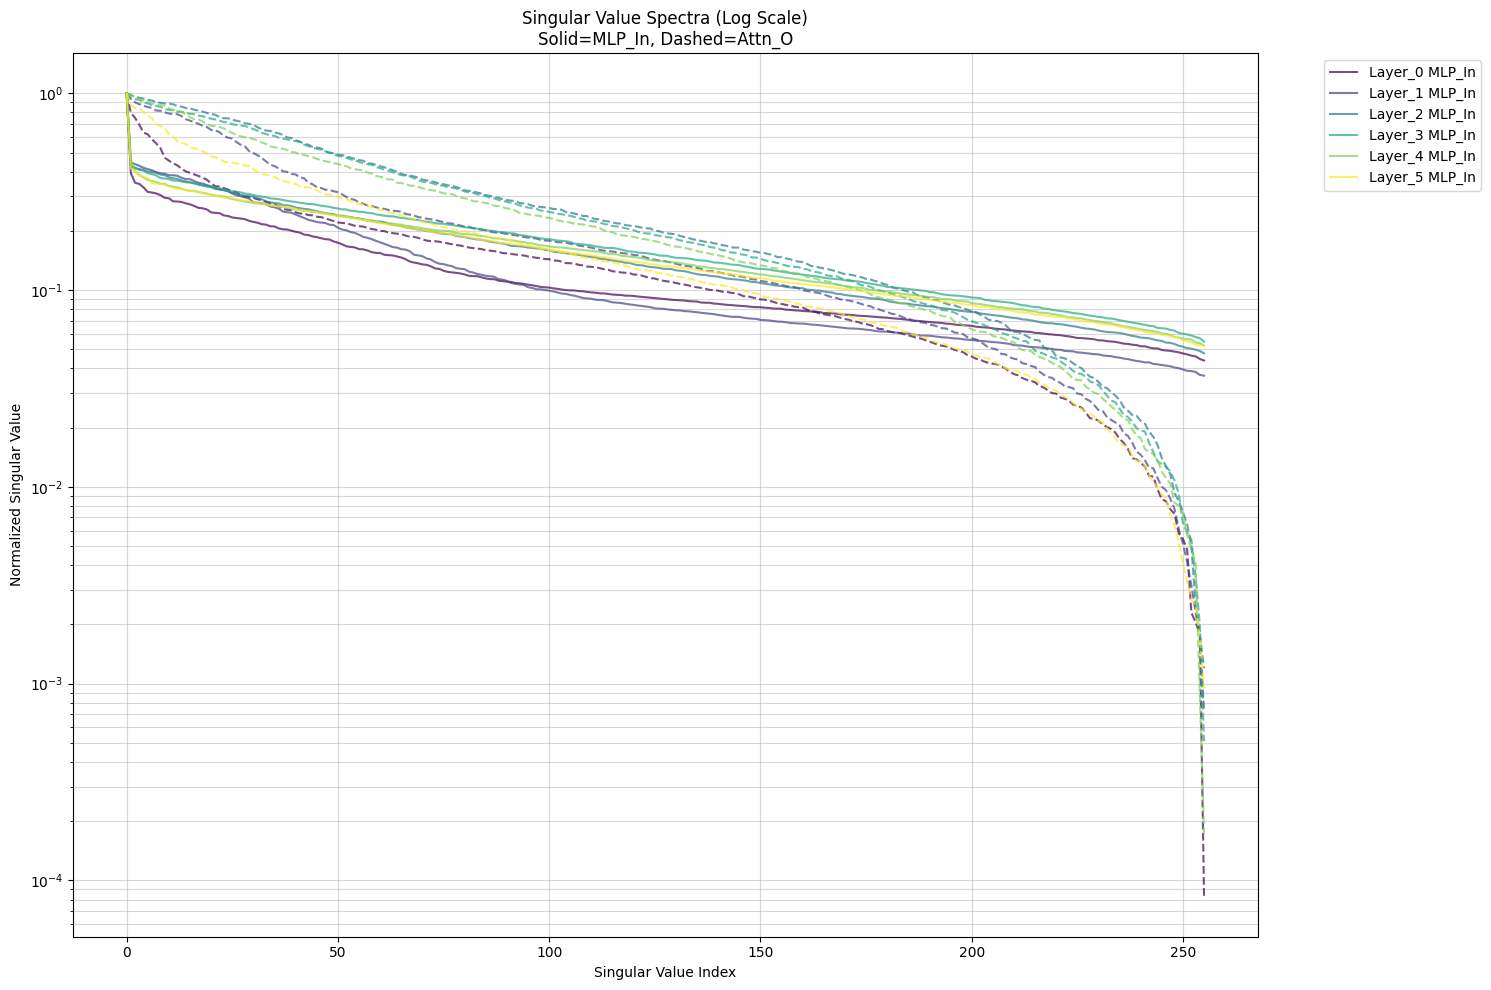

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def analyze_layer_spectra(model):
    results = {}

    # We iterate through layers to see if depth degrades rank
    for i, block in enumerate(model.transformer.h):
        layer_weights = {}

        # 1. Attention Weights
        # Q and K share spectra in this architecture due to orthogonal R
        # So we only grab Q, V, and O
        layer_weights['Attn_Q'] = block.attn.q_proj.weight.detach()
        layer_weights['Attn_V'] = block.attn.v_proj.weight.detach()
        layer_weights['Attn_O'] = block.attn.o_proj.weight.detach()

        # 2. MLP Weights
        layer_weights['MLP_In'] = block.mlp.c_fc.weight.detach()
        layer_weights['MLP_Out'] = block.mlp.c_proj.weight.detach()

        # Compute SVD
        # We look at the singular values (S) normalized by the largest value
        layer_spectra = {}
        for name, W in layer_weights.items():
            if W.ndim == 2:
                # SVD returns U, S, Vh. We only need S.
                # W is (Out, In). SVD handles non-square naturally.
                try:
                    _, S, _ = torch.linalg.svd(W.float())
                    # Normalize so max singular value is 1.0 (log scale visualization helper)
                    S_norm = S / S[0]
                    layer_spectra[name] = S_norm.cpu().numpy()
                except Exception as e:
                    print(f"Skipping {name} due to SVD error: {e}")

        results[f'Layer_{i}'] = layer_spectra

    return results

def plot_spectral_collapse(results):
    plt.figure(figsize=(15, 10))

    # We aggregate all layers to see the trend
    colors = plt.cm.viridis(np.linspace(0, 1, len(results)))

    for (layer_name, spectra), color in zip(results.items(), colors):
        # We create a subplot for each weight type if we want, or overlay them
        # Let's overlay them per layer to see if specific layers collapse

        # Flatten the spectra to average or just plot the MLP_In (usually the most robust)
        # vs Attn_O (usually the most collapsed)

        # Plotting MLP_In
        if 'MLP_In' in spectra:
            y = spectra['MLP_In']
            plt.plot(y, color=color, linestyle='-', alpha=0.7, label=f"{layer_name} MLP_In")

        # Plotting Attn_O
        if 'Attn_O' in spectra:
            y = spectra['Attn_O']
            # Dashed for attention
            plt.plot(y, color=color, linestyle='--', alpha=0.7)

    plt.yscale('log')
    plt.title('Singular Value Spectra (Log Scale)\nSolid=MLP_In, Dashed=Attn_O')
    plt.ylabel('Normalized Singular Value')
    plt.xlabel('Singular Value Index')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the analysis
# Assuming 'model' is already instantiated and on device (cpu or cuda)
spectra_data = analyze_layer_spectra(model)
plot_spectral_collapse(spectra_data)

Extracting neurons...
Computing 3D Manifold (this may take a moment)...


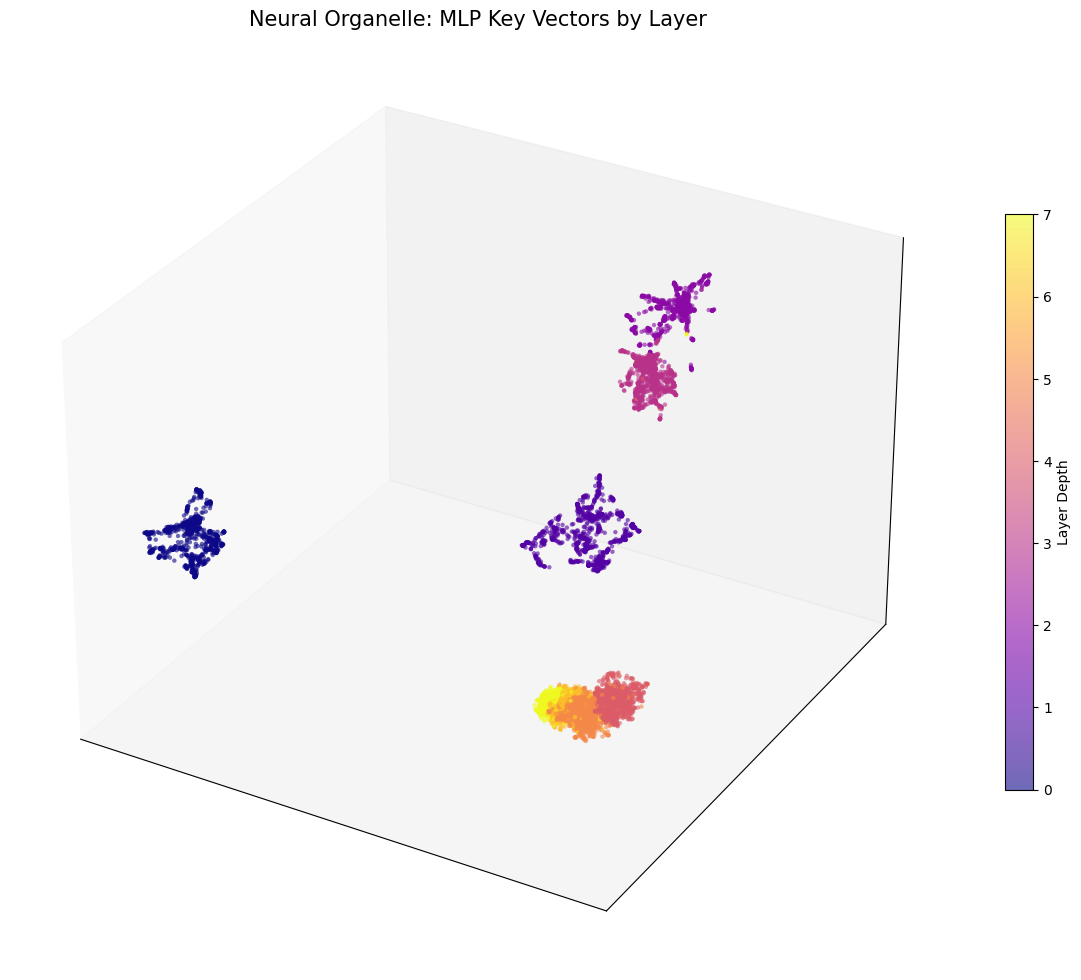

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap # pip install umap-learn

def visualize_organelle(model):
    # 1. Collect all MLP Neurons ("Detectors")
    # In GPT, the MLP up-projection (c_fc) reads from the embedding space.
    # Each row is a "neuron" looking for a specific direction in 128-dim space.

    all_neurons = []
    layer_labels = []

    print("Extracting neurons...")
    for i, block in enumerate(model.transformer.h):
        # Shape: [4 * n_embd, n_embd] -> [512, 128] for your config
        # We view these as 512 distinct vectors in 128-dim space
        weights = block.ffn.c_fc.weight.detach().cpu().numpy()
        all_neurons.append(weights)
        layer_labels.append(np.full(weights.shape[0], i)) # Track which layer owns the neuron

    # Concatenate to shape [Total_Neurons, n_embd]
    # For 4 layers * 512 neurons = 2048 points
    X = np.vstack(all_neurons)
    labels = np.concatenate(layer_labels)

    # 2. UMAP Projection (The "Organelle" Generator)
    # n_neighbors: Controls local vs global structure.
    #   Low (5-15) = fragmentation (many tiny blobs).
    #   High (50-100) = global shape (one big connected organelle).
    # min_dist: Controls how tightly points pack together.
    print("Computing 3D Manifold (this may take a moment)...")
    reducer = umap.UMAP(
        n_neighbors=5,
        min_dist=0.1,
        n_components=5,
        metric='cosine' # Cosine is critical for high-dim semantics
    )
    embedding = reducer.fit_transform(X)

    # 3. Visualization
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Color map matches the layer depth
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        embedding[:, 2],
        c=labels,
        cmap='plasma',
        s=10,
        alpha=0.6,
        edgecolor='none'
    )

    # Styling to look like the "Twitter render"
    ax.set_facecolor('white')
    ax.grid(False)
    ax.set_title("Neural Organelle: MLP Key Vectors by Layer", fontsize=15)

    # Add a color bar indicating depth
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label('Layer Depth')

    # Remove axis ticks for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.tight_layout()
    plt.show()

# Run it
visualize_organelle(model)

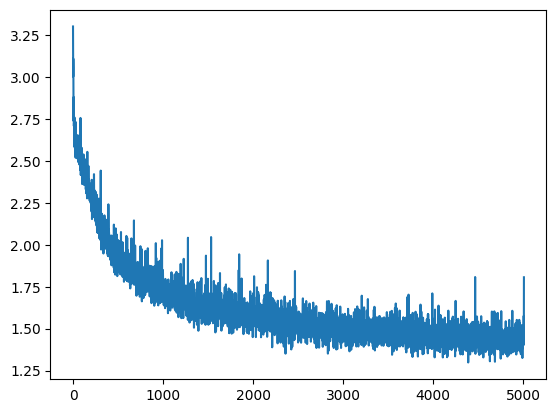

In [47]:
from matplotlib import pyplot as plt
plt.plot(losses[5:])
plt.show()

In [46]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=None):
    """
    Computes BPC and PPL on random contiguous slices.
    Assumes ?1 the loss returned by model(x, y) is mean NLL per token.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    total_nll_nat = 0.0
    total_tokens = 0

    for _ in range(max_batches):
        if len(val_ids) <= block_size + 1:
            break

        start = np.random.randint(0, len(val_ids) - block_size - 1)
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None, :]
        y = torch.tensor(val_ids[start+1:start+block_size+1], dtype=torch.long, device=device)[None, :]

        # IMPORTANT: pass y so the model returns a sequence loss
        logits, loss = model(x, y)
        loss=None
        # If model doesn’t return loss for some reason, compute it safely
        if loss is None:
            # Handle both possible logits shapes
            if logits.dim() == 3 and logits.size(1) == x.size(1):
                # full sequence logits [B, T, V]
                B, T, V = logits.shape
                ce = F.cross_entropy(logits.view(-1, V), y.view(-1), reduction="mean")
                nll_nat = ce.item()
                tokens = T * B
            elif logits.dim() == 2:
                # last-step logits [B, V] -> only evaluate the last target
                ce = F.cross_entropy(logits, y[:, -1], reduction="mean")
                nll_nat = ce.item()
                tokens = logits.size(0)  # B tokens (here 1)
            else:
                raise ValueError(f"Unexpected logits shape: {tuple(logits.shape)}")
        else:
            # ?1 assume this is mean NLL per token (standard)
            nll_nat = float(loss.item())
            tokens = x.numel()  # B * T

        total_nll_nat += nll_nat * tokens
        total_tokens  += tokens

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_nll_nat = total_nll_nat / total_tokens
    bpc = avg_nll_nat / np.log(2.0)
    ppl = float(np.exp(avg_nll_nat))
    return bpc, ppl,avg_nll_nat

bpc, ppl ,ce = eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=device)
print("BPC:", bpc, "Perplexity:", ppl, "VAL LOSS:", ce)


BPC: 2.0543753448808633 Perplexity: 4.153637590368294 VAL LOSS: 1.4239844781160356


'''
Negative log-likelihood (NLL): The metric underneath both BPC and PPL is the average negative log probability assigned to the true next token. Lower NLL means the model is assigning higher probability to correct targets → better performance.

BPC = NLL in bits per token. Lower BPC means fewer bits are needed to encode the text, i.e. the model compresses language better. A perfect model would reach 0.0 BPC.

PPL = exp(NLL). It represents the "effective branching factor" (how many equally likely next tokens the model is as uncertain between). Lower perplexity means the model is more confident and accurate. A perfect model would reach 1.0 PPL.
Models with <100k parameters usually collapse to gibberish or never beat 5-gram.
BPC of NGRAM is ~3.5-4
'''

In [48]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=1.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:
Ah, uncome come sent and Poes of I wont his nice 
wang out Cim we half drop yourscetalus of that! my lensis,
Thurd day,
Ve come from ached Me to Gorbeit thy thing.

QUEE CIOT:
Ay you will pothetol bible boy's hand,
Wait of marm's pathical.

CAPSIC:
How come on shee, done, two chernas he got name soul? what to, my hair mutter.

VORDY!
Looch fames and nemed noove wolfonds so thou half i want them behind it to it monude? he said
You a son afford she died outslord.

COADIO:
Thy lind oF st. sudantyng shall robert my hand our partner dill your polis:
Now but some of my daly!

CORDY:
I, lorm, is, unobveision the lord showne or the king?

CAMILLO:
Ml to more hath it radiors,
O.

FLONUNIUS:
At the next hearti-promise:
Aith-griem
Ue fand nor---
A man; and your rid; most wife.

KIVERSHAI:
Unsight I7:
Back.

PORIEE:
Yet Crofast the noble and he wing.
Hey less met her chaphis richia does the sewheish paying oh going, that all him me with a game free,
Dcar tiv

In [ ]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=0.00001
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:
I will be sworn to thee, by my mind.

JULIET:
Then let my heart with me to make them mock.

JULIET:
I will not make thee to the book of dog.

JULIET:
I will to the contagion, there is my soul.

JULIET:
Then let me hear thee sin to be sad;
But I am not to be satisfied. Thou know'st me.

JULIET:
I will be satisfied, when I shall deserve.

JULIET:
I will be satisfied, when I shall be so.

JULIET:
That is my heart is fair, too deep so far.

ROMEO:
Then move no tide that I may be satisfied.

JULIET:
Then let me hear thee since that I may save.

JULIET:
That is my heart is better than the world.

JULIET:
I will be satisfied, I will stay to hear,
To have the stones-born terror with the heels.

JULIET:
The sea should shed for the sea should see,
That made her silver comest to make her spotter:
So shall you bid me see that I shall say.

JULIET:
I will not make the torches that I may say.

JULIET:
The horrer hath made her butcher of these moans--
Which hea

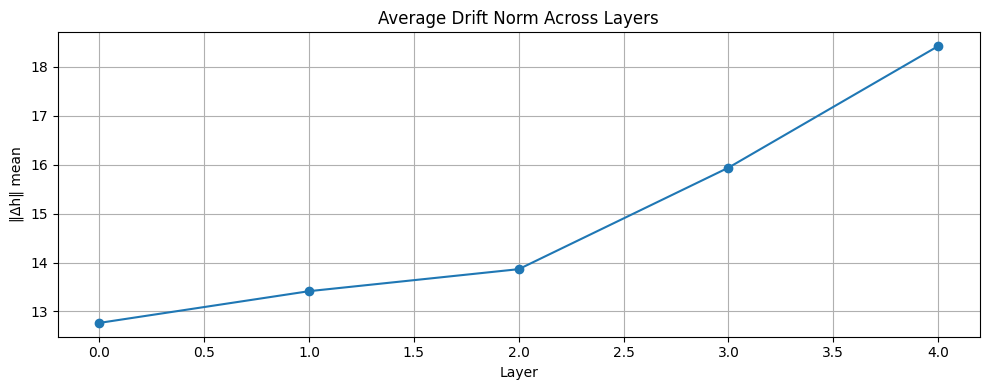

Jacobian rank (final token, projected): 57


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
'''
     def forward(self, idx, targets=None):
        device = idx.device
        b, T = idx.size()

        # forward the GPT model itself
        x = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)

            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

'''


@torch.no_grad()
def compute_drift_trajectories(model, idx, pad_token_id=None):
    """
    Drift vectors Δh_l = h_{l+1} - h_l aligned to the shrinking time axis.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?1 default=0 if None)
    returns: list of arrays, one per layer-gap, each shaped [B]
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx
    # forward the GPT model itself


    # token + pos emb
    x =norm( model.transformer.wte(tok))
    layers = []
    new_k = None
    with torch.no_grad():
        for block in model.transformer.h:
            x,new_k = block(x,new_k)         # time shrinks by n_head each block (per your setup)
            layers.append(x.clone()) # store aligned outputs

    # compute drifts with alignment: previous tail matches current length
    drifts = []
    for i in range(len(layers) - 1):
        a = layers[i]
        b = layers[i + 1]
        a_aligned = a[:, -b.size(1):, :]
        d = (b - a_aligned)
        drifts.append(d.norm(dim=-1).mean(dim=-1).cpu().numpy())  # [B]
    return drifts


def compute_jacobian_rank(model, idx, projection_dim=324, pad_token_id=None):
    """
    Rank of Jacobian d logits_proj(T_final) / d emb(T_input_last) with pad-once and shrink.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?2 default=0 if None)
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # embeddings with grad
    tok_emb =norm( model.transformer.wte(tok))
    emb = tok_emb
    def forward_emb(x):
        new_k = None
        for block in model.transformer.h:
            x,new_k = block(x,new_k)         # time shrinks by n_head each block (per your setup)
        x = norm(x)
        logits =  model.lm_head(x)    # [B, T_out, V]
        return logits[:, -1, :projection_dim]  # final token after shrink, projected

    output = forward_emb(emb)         # [B, P]
    jac_rows = []
    for i in range(output.shape[-1]):
        go = torch.zeros_like(output)
        go[:, i] = 1.0
        gi = grad(output, emb, grad_outputs=go, retain_graph=True)[0]  # [B, T_all, C]
        jac_rows.append(gi[:, -1, :].detach().cpu().numpy().squeeze()) # grad w.r.t. last input step
    J = np.stack(jac_rows, axis=0)     # [P, C]
    return int(np.linalg.matrix_rank(J))

def plot_drift(drift_norms):
    """
    Plot average drift norm per layer.
    """
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(d) for d in drift_norms], marker='o')
    plt.title("Average Drift Norm Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("‖Δh‖ mean")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

jac_rank = compute_jacobian_rank(model, input_ids)

drift_norms = compute_drift_trajectories(model, input_ids)
plot_drift(drift_norms)

print("Jacobian rank (final token, projected):", jac_rank)

In [17]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def collect_drift_matrix(model, idx, pad_token_id=None):
    """
    Build a drift matrix by stacking aligned per-layer deltas:
      Δ_l = h_{l+1} - tail_match(h_l)
    Tail-match aligns time since each block trims from the left.

    idx: [B, T_visible]
    pad_token_id: ?1 left-pad token id; default 0 if None
    returns: torch.FloatTensor [N, D] on CPU where N = sum_l B * T_l
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # 2) embed like forward() does
    x = norm(model.transformer.wte(tok))
    # 3) collect per-block states (time shrinks each block)
    states = []
    with torch.no_grad():
        new_k = None
        for block in model.transformer.h:
            x,new_k = block(x,new_k)         # time shrinks by n_head each block (per your setup)
            states.append(x.clone())

    # 4) aligned drifts: match tail of h_l to h_{l+1}
    drift_chunks = []
    for i in range(len(states) - 1):
        a = states[i]       # [B, T_a, C]
        b = states[i + 1]   # [B, T_b, C], T_b <= T_a
        a_aligned = a[:, -b.size(1):, :]     # tail-match
        d = (b - a_aligned).reshape(-1, b.size(-1))  # [B*T_b, C]
        drift_chunks.append(d.cpu())

    drift_matrix = torch.cat(drift_chunks, dim=0) if drift_chunks else torch.empty(0, x.size(-1))
    return drift_matrix  # [N, D] on CPU


def run_drift_pca(drift_matrix, k=40):
    """
    PCA on drift samples. drift_matrix can be torch.Tensor [N, D] (CPU or CUDA) or np.ndarray.
    """
    if isinstance(drift_matrix, torch.Tensor):
        drift_np = drift_matrix.detach().cpu().numpy()
    else:
        drift_np = np.asarray(drift_matrix)
    k = min(k, drift_np.shape[0], drift_np.shape[1])  # guard
    pca = PCA(n_components=k)
    pca.fit(drift_np)
    explained = pca.explained_variance_ratio_
    return explained, pca


def plot_explained_variance(explained):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Drift Trajectory PCA: Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

def get_projected_residuals(drift_matrix, pca):
    """
    Project Δh onto PCA space and get residuals.
    """
    proj = pca.transform(drift_matrix.numpy())
    recon = pca.inverse_transform(proj)
    residuals = drift_matrix.numpy() - recon
    return proj, residuals

def fit_gmm(proj_data, k=4):
    """
    Fit GMM to PCA-projected drift vectors to identify latent regimes.
    """
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(proj_data)
    labels = gmm.predict(proj_data)
    return gmm, labels

def plot_gmm_clusters(proj_data, labels):
    """
    Plot GMM clustering over first 2 PCA components.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=labels, palette="tab10", s=10)
    plt.title("Latent Regimes from Drift PCA (GMM Clusters)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


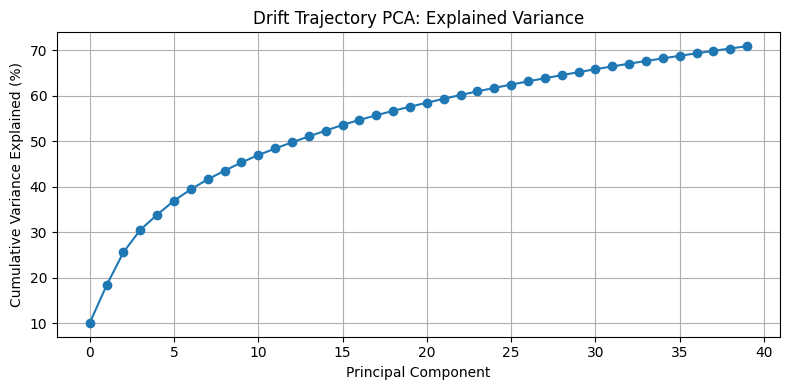

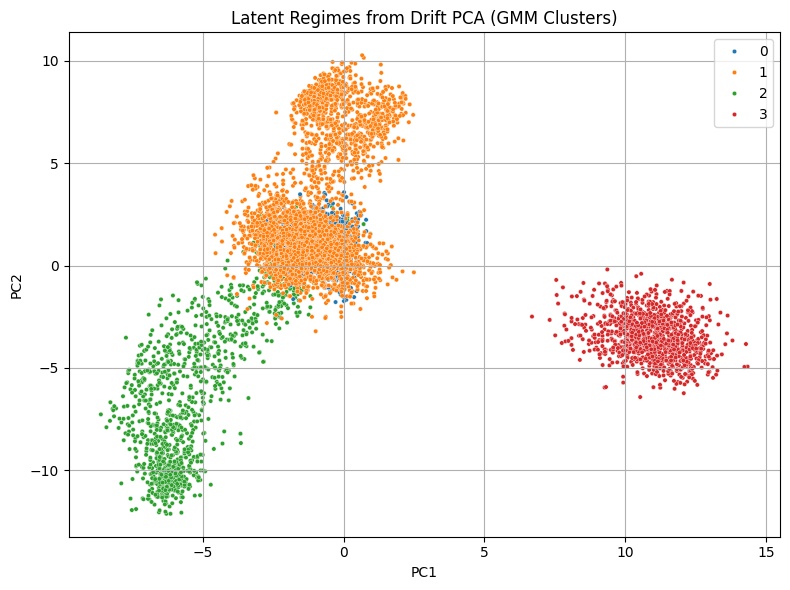

In [49]:
# Inputs
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

# Drift matrix
drift_matrix = collect_drift_matrix(model, input_ids)

# PCA and variance
explained, pca = run_drift_pca(drift_matrix, k=40)
plot_explained_variance(explained)

# Residuals and GMM regime fit
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=4)
plot_gmm_clusters(proj, labels)


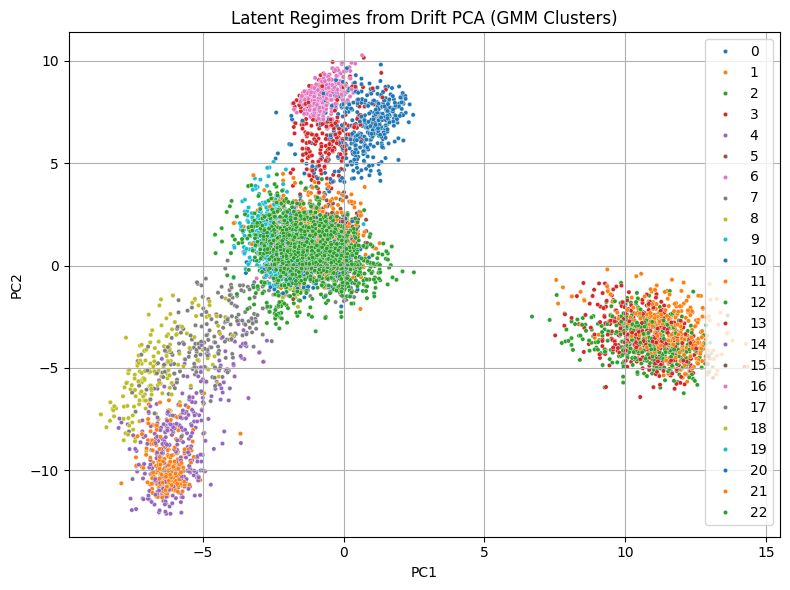

In [50]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=23)
plot_gmm_clusters(proj, labels)

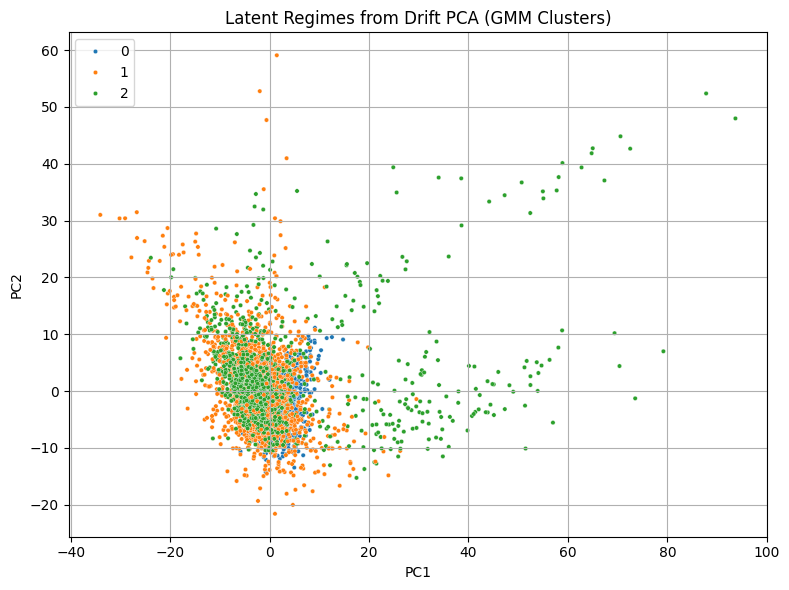

In [ ]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=3)
plot_gmm_clusters(proj, labels)

[Baseline] Val loss: 2.7324

--- Per-Layer Ablation Report ---
Ablate Layer  0: Loss = 2.8325 | Δ = 0.1001
Ablate Layer  1: Loss = 2.7834 | Δ = 0.0510
Ablate Layer  2: Loss = 2.6328 | Δ = -0.0996
Ablate Layer  3: Loss = 2.7173 | Δ = -0.0152


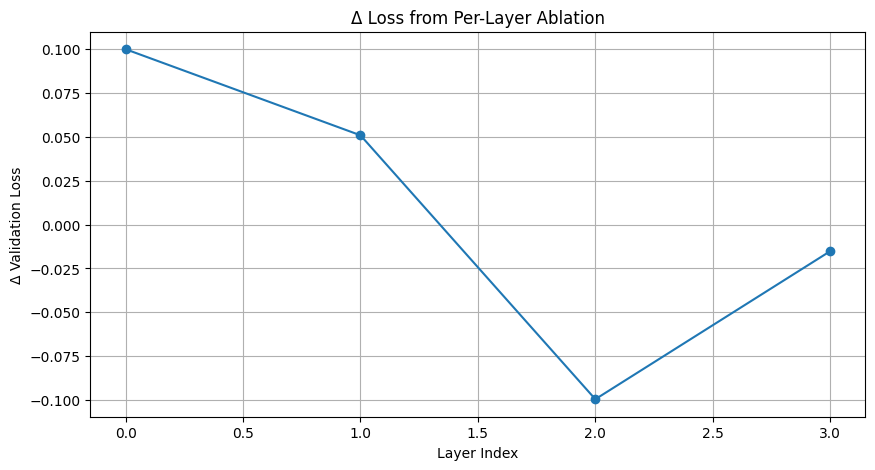

In [ ]:
import matplotlib.pyplot as plt
from contextlib import contextmanager
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

# ==============================
# 🔁 LAYER ABLATION LOGIC BLOCK
# =============================

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 1
# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap data (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.total = len(self.data) - block_size - 1

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.block_size), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)
        for i in range(self.batch_size):
            start = np.random.randint(0, self.total // self.block_size) * self.block_size
            X[i] = self.data[start : start + self.block_size]
            Y[i] = self.data[start + 1 : start + 1 + self.block_size]
        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )

val_dataset = GPUBatchDataset(val_ids, block_size, batch_size=1, device=device)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()
losses = []
@contextmanager
def layer_ablation_context(model, layers_to_ablate):
    """Context manager that safely ablates selected layers by overriding their .forward."""
    original_forwards = [block.forward for block in model.transformer.h]

    def make_ablation_forward(index, original_fn):
        def ablated_forward(x):
            out = original_fn(x)
            return out
        return ablated_forward

    try:
        for i, block in enumerate(model.transformer.h):
            if i in layers_to_ablate:
                model.transformer.h[i].forward = make_ablation_forward(i, original_forwards[i])
        yield
    finally:
        # Always restore the original forwards
        for i, block in enumerate(model.transformer.h):
            model.transformer.h[i].forward = original_forwards[i]

@torch.no_grad()
def eval_epoch(max_batches=50):
    model.eval()
    total_loss = 0
    for i, (xb, yb) in enumerate(val_loader):
        if i >= max_batches:
            break
        xb, yb = xb[0], yb[0]
        logits, _ = model(xb, yb)
        B, T, V = logits.shape
        total_loss += criterion(logits.view(B * T, V),
                                yb.view(B * T)).item()
    return total_loss / max_batches

# ---- Evaluate baseline without any ablation ----
with layer_ablation_context(model, layers_to_ablate=set()):
    baseline_val_loss = eval_epoch()
print(f"[Baseline] Val loss: {baseline_val_loss:.4f}")

# ---- Run per-layer ablation safely ----
print("\n--- Per-Layer Ablation Report ---")
results = []
for i in range(model.config.n_layer):
    with layer_ablation_context(model, layers_to_ablate={i}):
        loss = eval_epoch()
    delta = loss - baseline_val_loss
    results.append((i, loss, delta))
    print(f"Ablate Layer {i:2d}: Loss = {loss:.4f} | Δ = {delta:.4f}")

# ---- Plotting ----
layer_ids = [i for i, _, _ in results]
delta_vals = [delta for _, _, delta in results]

plt.figure(figsize=(10, 5))
plt.plot(layer_ids, delta_vals, marker='o')
plt.title("Δ Loss from Per-Layer Ablation")
plt.xlabel("Layer Index")
plt.ylabel("Δ Validation Loss")
plt.grid(True)
plt.show()


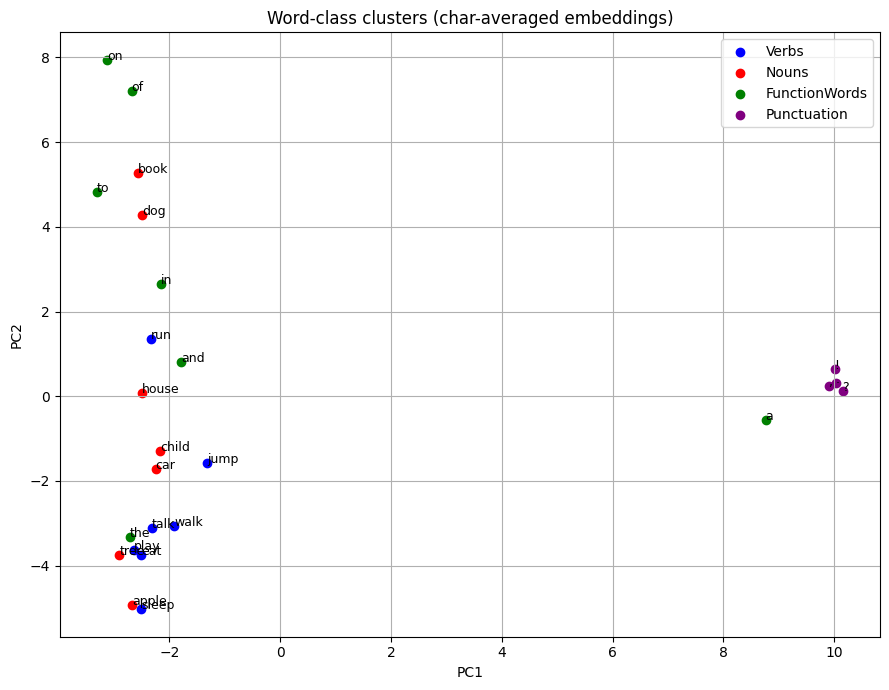

In [ ]:
import torch, pickle, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# ---------- load vocab ----------
with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi, itos = meta["stoi"], meta["itos"]

# ---------- model bits ----------
device = next(model.parameters()).device
model.eval()                      # <— turn off dropout everywhere
wte = model.transformer.wte
wte.eval()

@torch.no_grad()
def get_char_embedding(word):
    ids = [stoi[c] for c in word if c in stoi]
    if len(ids) < 2:              # ← need ≥2 chars for HailFire geometry
        return None
    with torch.no_grad():
        t = torch.tensor(ids, device=device).unsqueeze(0)      # [1, T]
        emb = model.transformer.wte(t).mean(dim=1).squeeze(0)                    # (d,)
        return emb.cpu().numpy()

# ---------- categories ----------
categories = {
    "Verbs":        ["play","run","eat","sleep","jump","talk","walk"],
    "Nouns":        ["dog","tree","car","book","child","house","apple"],
    "FunctionWords":["the","and","in","on","to","of","a   "],
    "Punctuation":  [".    ",",    ","!    ","?    "],
}

# ---------- gather ----------
vecs, labels, words = [], [], []
for cat, wl in categories.items():
    for w in wl:
        v = get_char_embedding(w)
        if v is not None:
            vecs.append(v)
            labels.append(cat)
            words.append(w)

vecs = np.stack(vecs)             # ← now guaranteed rectangular

# ---------- PCA ----------
proj = PCA(n_components=2).fit_transform(vecs)

# ---------- plot ----------
colors = dict(Verbs="blue", Nouns="red",
              FunctionWords="green", Punctuation="purple")

plt.figure(figsize=(9,7))
for cat in categories:
    idx = [i for i,l in enumerate(labels) if l==cat]
    plt.scatter(proj[idx,0], proj[idx,1], label=cat, color=colors[cat])
    for i in idx:
        plt.text(proj[i,0], proj[i,1], words[i], fontsize=9)

plt.title("Word-class clusters (char-averaged embeddings)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()


In [51]:
PATH = "overfitshakespeare_tiny.pt"

# Save the state_dict
torch.save(model.state_dict(), PATH)

In [ ]:
import torch

def analyze_logit_magnitude(model, loader):
    # Set model to eval to disable dropout/norm updates
    model.eval()

    # Extract one batch from the loader logic provided
    iterator = iter(loader)
    xb, yb = next(iterator)

    # Mimic the unwrapping from your training loop
    if isinstance(xb, list) or (isinstance(xb, torch.Tensor) and xb.dim() > 2):
        xb = xb[0]

    # Ensure context is on the correct device
    device = next(model.parameters()).device
    context = xb.to(device)

    print(f"Context shape: {context.shape}")

    with torch.no_grad():
        # Forward pass
        logits, _ = model(context)

        # Select the logits for the last token in the sequence
        # Shape: (Batch, Time, Vocab) -> select one batch, last time step
        last_logits = logits[0, -1, :]

        max_val = last_logits.max().item()
        min_val = last_logits.min().item()
        mean_val = last_logits.mean().item()
        spread = max_val - min_val

        print("--- Logit Explosion Check ---")
        print(f"Max Logit:   {max_val:.4f}")
        print(f"Min Logit:   {min_val:.4f}")
        print(f"Mean Logit:  {mean_val:.4f}")
        print(f"Spread:      {spread:.4f}")

        # Calculate the temperature required to return this to a normal variance (assuming ~10 spread is normal)
        print(f"Effective Temp needed to normalize: {spread / 10:.2f}")
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)

# Execute
analyze_logit_magnitude(model, train_loader)

Context shape: torch.Size([8, 1024])
--- Logit Explosion Check ---
Max Logit:   10.6971
Min Logit:   -15.7933
Mean Logit:  -5.6531
Spread:      26.4905
Effective Temp needed to normalize: 2.65


In [ ]:
import random
import torch

def run_diagnostics(model, full_train_text, stoi, itos):
    print(f"--- 🧪 DIAGNOSTIC SUITE ---")

    # === TEST 1: The Verbatim Probe (Memory Check) ===
    # We grab a random sequence, feed the first half, and see if the model
    # perfectly reproduces the second half.

    seq_len = 128
    split = seq_len // 2
    samples = 5
    matches = 0

    print(f"\n[1] Verbatim Memorization Probe (n={samples})")
    print(f"    Condition: Temperature=0.00001 (Argmax proxy)")

    for i in range(samples):
        # Pick random slice
        start_idx = random.randint(0, len(full_train_text) - seq_len - 1)
        truth = full_train_text[start_idx : start_idx + seq_len]

        prompt_segment = truth[:split]
        target_segment = truth[split:]

        # Generate
        full_output = decode_sequence_char(
            model=model,
            stoi=stoi,
            itos=itos,
            prompt=prompt_segment,
            max_new_tokens=len(target_segment), # exact length match
            block_size=1024,
            temperature=1e-5 # Force greedy decoding
        )

        # Strip prompt to get just the generation
        # (Your function returns prompt + generation)
        generated_part = full_output[len(prompt_segment):]

        # Compare
        is_exact = (generated_part == target_segment)
        if is_exact: matches += 1

        status = "✅ MEMORY HIT" if is_exact else "❌ NO MATCH"
        print(f"\nSample {i+1}: {status}")
        print(f"Prompt:   {repr(prompt_segment)}")
        print(f"Expected: {repr(target_segment)}")
        print(f"Got:      {repr(generated_part)}")

    print(f"\nScore: {matches}/{samples}")
    if matches >= 4:
        print(">> RESULT: HIGH MEMORIZATION. Model is acting as a lookup table.")
    else:
        print(">> RESULT: LOW MEMORIZATION. Model is hallucinating/overfitting patterns.")

    # === TEST 2: The Adversarial Scaffold ===
    # We feed a format that looks like valid dialogue but uses tokens/names
    # that (likely) don't exist in the training set to break the lookup key.

    print(f"\n[2] Adversarial Scaffold Test")
    print("    Prompt: 'CYBERPUNK: The system is down. JULIET:'")

    scaffold = "CYBERPUNK: The system is down. JULIET:"

    adv_output = decode_sequence_char(
        model=model,
        stoi=stoi,
        itos=itos,
        prompt=scaffold,
        max_new_tokens=100,
        block_size=1024,
        temperature=1.0 # Normal sampling
    )

    print(f"    Result: {repr(adv_output[len(scaffold):])}")
    print("    Interpretation: If result is nonsense or reverts to 'ROMEO:', indexing failed.")
    print("                    If result creates a plausible Juliet line, it has generalized syntax.")

# Execute
# Assumes 'full_train' string is still in memory from your previous script.
# If not, reload it: full_train = open("babylm_10m_cleaned/shakespeare.txt").read() ...
run_diagnostics(model, full_train, stoi, itos)

--- 🧪 DIAGNOSTIC SUITE ---

[1] Verbatim Memorization Probe (n=5)
    Condition: Temperature=0.00001 (Argmax proxy)

Sample 1: ❌ NO MATCH
Prompt:   "d not be satisfied!\n\nSon:\nWas ever son so rued a father's death?"
Expected: "\n\nFather:\nWas ever father so bemoan'd his son?\n\nKING HENRY VI:\nW"
Got:      "\n\nSTANLEY:\nI am too hot.\n\nPETRUCHIO:\n'Tis better so great a word"

Sample 2: ❌ NO MATCH
Prompt:   'om\nmy son Coriolanus: guess, but by my entertainment\nwith him, i'
Expected: "f thou standest not i' the state of\nhanging, or of some death mo"
Got:      "f thou standest not i' the stars : thou\nwilt be pity to all the "

Sample 3: ❌ NO MATCH
Prompt:   'od to make the lodging sweet:\nProcure me music ready when he wak'
Expected: 'es,\nTo make a dulcet and a heavenly sound;\nAnd if he chance to s'
Got:      'es,\nTo make a dull and a heavier guide.\nSee, see! dwell, Warwick'

Sample 4: ❌ NO MATCH
Prompt:   ' lord, lest all the land do rue it.\n\nGLOUCESTER:\nWould you enfor'

In [ ]:
prompts = [
    "ROMEO:\nCome, gentle night, come, loving black-brow'd night,\nGive me my",
    "NURSE:\nI am none of his flirt-gills; I am none of his",
    "MERCUTIO:\nIf love be rough with you, be rough with love;\nPrick",
    "JULIET:\nSpread thy close curtain, love-performing night,\nThat",
    "PETRUCHIO:\nWho knows not where a wasp does wear his sting?\nIn his",
    "MERCUTIO:\nO, that she were\nAn open-arse, thou a",
    "CLEOPATRA:\nO happy horse, to bear the weight of",
    "NURSE:\nNow comes the wanton blood up in your cheeks,\nThey'll be in",
    "BENEDICK:\nI would my horse had the speed of your tongue, and\nso good a",
    "POMPEY:\nDoes your worship mean to geld and splay all the\nyouth of the",
    "TITANIA:\nCome, sit thee down upon this flowery bed,\nWhile I thy amiable",
    "MERCUTIO:\nBy my heel, I care not.\nROMEO:\nThy wit is a very bitter sweeting;\nit is a most sharp",
]

for i, p in enumerate(prompts):
    out = decode_sequence_char(
        model=model, stoi=stoi, itos=itos,
        prompt=p, max_new_tokens=80,
        block_size=1024, temperature=0.9
    )
    continuation = out[len(p):]
    print(f"\n--- Sample {i+1} ---")
    print(f"PROMPT: {repr(p)}")
    print(f"CONTINUATION: {repr(continuation)}")


--- Sample 1 ---
PROMPT: "ROMEO:\nCome, gentle night, come, loving black-brow'd night,\nGive me my"
CONTINUATION: " master's sweet butcher than my stree:\nA gripe in the woman's queen with me of i"

--- Sample 2 ---
PROMPT: 'NURSE:\nI am none of his flirt-gills; I am none of his'
CONTINUATION: '\nben known with some musiciately in his house,\nhe may, indeed-babes to be a gent'

--- Sample 3 ---
PROMPT: 'MERCUTIO:\nIf love be rough with you, be rough with love;\nPrick'
CONTINUATION: 'ing it two, and reverend of some place!\n\nBENVOLIO:\nWith a talk, ay, but one of t'

--- Sample 4 ---
PROMPT: 'JULIET:\nSpread thy close curtain, love-performing night,\nThat'
CONTINUATION: " Englishman slain wounded Ulyssip's tongue.\n\nBENVOLIO:\nMy heart enjoys are under"

--- Sample 5 ---
PROMPT: 'PETRUCHIO:\nWho knows not where a wasp does wear his sting?\nIn his'
CONTINUATION: " tongue's shame, creeping him, he disconsent\n\nan early chaste in thy life and ho"

--- Sample 6 ---
PROMPT: 'MERCUTIO:\nO